# 🚀 YOLOv8 Object Detection on Pascal VOC (KerasCV)

---

# 1️⃣ Introduction to Pascal VOC and YOLOv8

## 📌 Pascal VOC Dataset

The **Pascal Visual Object Classes (VOC)** dataset is a classical benchmark in object detection.

It contains **20 object categories**:

- Vehicles
- Animals
- Indoor objects
- Persons

These classes are:

- aeroplane, bicycle, bird, boat, bottle  
- bus, car, cat, chair, cow  
- diningtable, dog, horse, motorbike, person  
- pottedplant, sheep, sofa, train, tvmonitor  

---

## 📌 YOLOv8 Overview

YOLOv8 is a modern anchor-based object detector that:

- Uses feature pyramids  
- Performs classification + box regression jointly  
- Applies built-in NMS  
- Outputs final filtered detections directly  

Unlike YOLOv2:
- No manual decoding required  
- No manual NMS required  
- No session handling  
- Fully TF2 compatible  

---

## 📐 Bounding Box Format

We use:



$$
(x, y, w, h)
$$



Where:
- $(x, y)$ → center coordinates  
- $(w, h)$ → width and height  

This is called **xywh format**.

---

# 2️⃣ Define VOC Class Labels


In [1]:
voc_classes = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

### Why Define Class Mapping?

The model outputs numeric class IDs:

$$
\text{class\_id} \in [0, 19]
$$

We map:

$$
\text{id} \rightarrow \text{human-readable class name}
$$

This improves visualization and interpretability.

# 3️⃣ Load Pretrained YOLOv8 Pascal VOC Model

In [2]:
import tensorflow as tf
import keras_cv

# Load PascalVOC pretrained YOLOv8 detector (20 classes)
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

## 🔍 What is Happening Here?

We load a pretrained model using:

**`YOLOV8Detector.from_preset()`**

Preset used:  
- `"yolo_v8_m_pascalvoc"`  
- YOLOv8 Medium backbone  
- Trained on Pascal VOC  
- 20 classes  
- Pretrained weights included  

---

## 📐 Why Specify `bounding_box_format="xywh"`?

KerasCV supports multiple bounding box formats:

- **xywh**  
- **xyxy**  
- **rel_xywh**  
- **rel_xyxy**  

Specifying the format ensures:
- ✅ Correct decoding  
- ✅ Correct visualization  
- ✅ Correct scaling  

Always match the format across:
- Model  
- Visualization  
- Evaluation  


# 4️⃣ Load and Preprocess Image

In [3]:
# Load and resize image
image = tf.keras.utils.load_img("test.jpg", target_size=(640, 640))

# Convert to numpy array
image_array = tf.keras.utils.img_to_array(image)

# Add batch dimension
image_array = tf.expand_dims(image_array, axis=0)


## 📌 Why Resize to 640×640?

YOLOv8 expects a **fixed input size**.  
Resizing ensures:

- ✅ Correct tensor dimensions  
- ✅ Proper feature map generation  
- ✅ No shape mismatch errors  

---

## 📌 Why Add Batch Dimension?

The model expects input in the format:



$$
(batch,\; height,\; width,\; channels)
$$



So we expand:



$$
(640,\;640,\;3) \;\;\rightarrow\;\; (1,\;640,\;640,\;3)
$$



This ensures the image is treated as a batch of size 1, which is required for inference in TensorFlow/KerasCV.


# 5️⃣ Run Inference

In [4]:
# Run inference
predictions = model.predict(image_array)


1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


## 🔍 What Does model.predict() Return?

YOLOv8 in KerasCV returns structured predictions:

```python
{
  "boxes": Tensor,
  "classes": Tensor,
  "confidence": Tensor
}
```
- Boxes already decoded
- NMS already applied
- Scores thresholded
- Ready for visualization

# 6️⃣ Draw Bounding Boxes

In [5]:
drawn_images = keras_cv.visualization.draw_bounding_boxes(
    image_array,
    predictions,
    bounding_box_format="xywh",
    color=(255, 0, 0),
    class_mapping={i: name for i, name in enumerate(voc_classes)},
    line_thickness=1,
    font_scale=0.4,
    text_thickness=1,
)


## 📌 Visualization Pipeline

The visualization step handles how detections are displayed on the image. It:

- ✅ Draws rectangle borders  
- ✅ Writes class labels  
- ✅ Writes confidence scores  
- ✅ Supports batch input  

---

## 🏷 Class Mapping Explained

We pass a dictionary mapping numeric IDs to human-readable class names:

```python
{
  0: "aeroplane",
  1: "bicycle",
  2: "bird",
  ...
}
```

This converts:



$$
\text{class id} \;\;\rightarrow\;\; \text{class name}
$$



Without mapping, the visualization would display only numeric IDs, making interpretation less intuitive.


# 7️⃣ Display Final Image

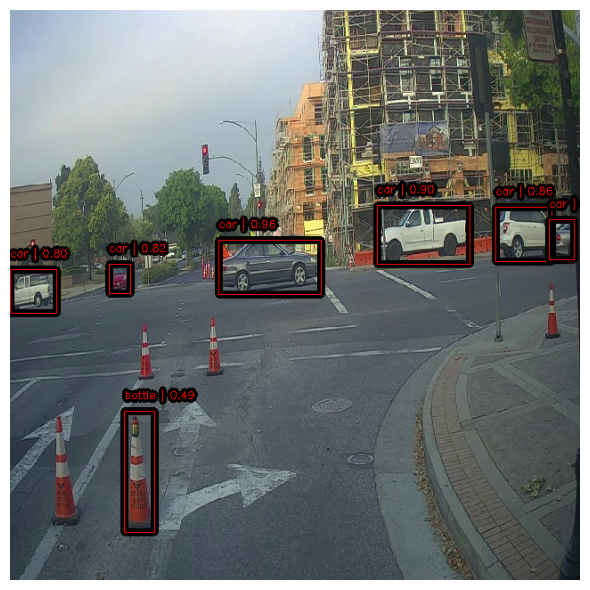

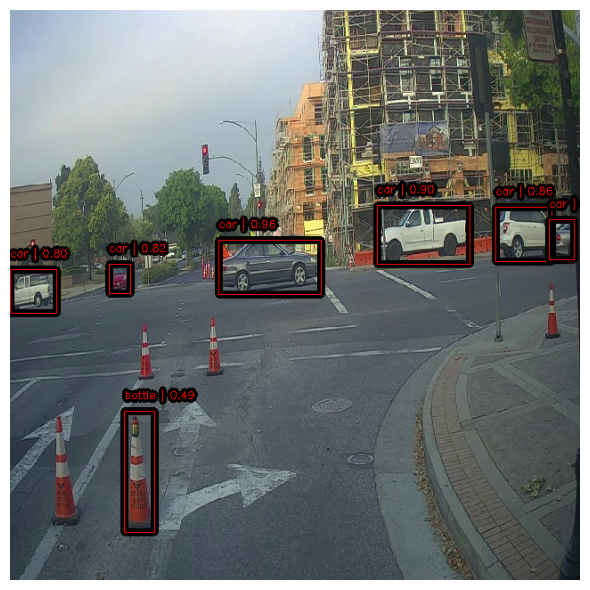

In [6]:
keras_cv.visualization.plot_image_gallery(
    drawn_images,
    value_range=(0, 255),
    scale=6,
    rows=1,
    cols=1
)


## 📌 What Does This Do?

- Displays image in notebook
- Handles batch visualization
- Automatically scales display size

# 🧠 Deep Conceptual Understanding

## 🔄 Full Detection Pipeline (Modern YOLOv8)

```text
Input Image (640x640)
        ↓
Backbone (Feature Extraction)
        ↓
Neck (Feature Pyramid)
        ↓
Detection Head
        ↓
Box Regression + Classification
        ↓
Built-in NMS
        ↓
Final Predictions
        ↓
Visualization
```

# 🎯 Final Takeaways

- YOLOv8 abstracts complex postprocessing
- Predictions are fully decoded
- NMS is applied internally
- Only visualization and class mapping are required
- KerasCV makes detection pipeline production-ready